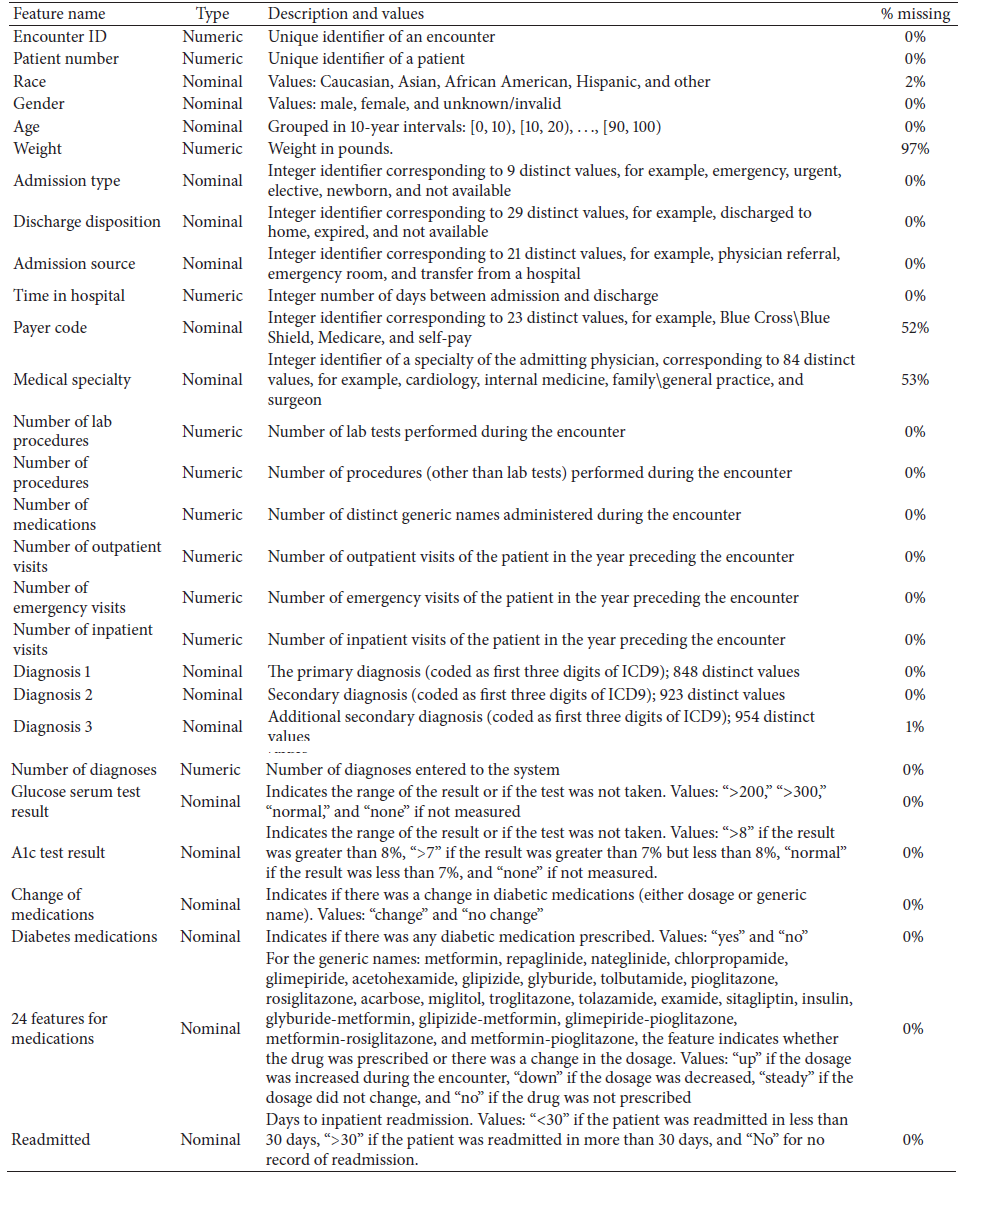

* USING THIS CHART ONLY FOR THE DESCRIPTION. MOREOVER THE MISSING VALUE PERCENTAGE IS WRONG HERE

In [27]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# reading the dataset 
dia_df = pd.read_csv('./diabetic_data.csv')
dia_df.sample(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
90008,292065684,38532609,AfricanAmerican,Male,[30-40),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,NO
64329,179047134,23643009,Caucasian,Male,[60-70),?,3,1,1,1,...,No,No,No,No,No,No,No,No,Yes,NO
91928,315556382,119003909,Caucasian,Female,[70-80),?,1,1,7,3,...,No,Steady,No,No,No,No,No,No,Yes,NO
88621,285227532,42965991,AfricanAmerican,Female,[60-70),?,1,1,7,2,...,No,Down,No,No,No,No,No,Ch,Yes,NO
43937,135548562,61149402,Caucasian,Male,[80-90),?,1,11,7,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
75288,225586044,42812883,Caucasian,Female,[60-70),?,3,1,1,2,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
26774,88038438,14760162,AfricanAmerican,Female,[70-80),?,2,6,1,6,...,No,No,No,No,No,No,No,No,Yes,<30
40745,126390210,41973417,Caucasian,Male,[30-40),?,1,1,7,1,...,No,No,No,No,No,No,No,No,No,>30
38928,121076370,97250616,Hispanic,Female,[70-80),?,6,25,17,3,...,No,No,No,No,No,No,No,No,No,NO
80246,247119924,1914993,Caucasian,Female,[60-70),?,3,1,1,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# UNDERSTANDING THE DATASET

In [29]:
dia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [30]:
# checking for null values
dia_df.isna().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

* OBSERVATION : AS WE CAN THE NUMBER OF MISSING VALUES IN COLUMN 'MAX_GLU_SERUM' AND A1CRESULT IS QUITE HIGH. SO I THINK THE BEST OPTION HERE IS TO DROP THEM

In [31]:
dia_df.drop(['max_glu_serum','A1Cresult'],inplace=True,axis=1)

* OBSERVATION : COLUMNS LIKE PATIENT ID AND RACE ARE NOT REQUIRED

In [32]:
dia_df.drop(['encounter_id','patient_nbr','race'],inplace=True, axis = 1)

In [33]:
dia_df.weight.value_counts()

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

* OBSERVATION : THE WEIGHT COLUMN HAS MORE 96000 VALUE AS '?' SO IT BEST TO DROP IT

In [34]:
dia_df.drop('weight',inplace=True, axis = 1)

# FINDING UNIQUE VALUES OF EVERY COLUMN 

In [35]:
categorical_cols = dia_df.select_dtypes(include='object').columns.tolist()

for cols in categorical_cols:
    unique_values = dia_df[cols].value_counts()
    print(f'Column : {cols}')
    print(f'Unique value : {unique_values}')
    print("\n")

Column : gender
Unique value : gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


Column : age
Unique value : age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64


Column : payer_code
Unique value : payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64


Column : medical_specialty
Unique value : medical_specialty
?                         49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Proctology                    1
Speech                        1
SportsMedicin

# OBSERVATION

* HERE CERTAIN COLUMNS STILL HAS '?' AS VALUE. DATA HERE MISSING IS ALMOST 40-49% SO IT IS FOR THE BEST TO DROP IT 
* CERTAIN COLUMNS HAS ONLY 'NO' AS VALUE SO IT IS USELESS
* AGE IS GIVEN IN SERIES SO I SHOULD MAP IT 

In [36]:
# having too many missing values
dia_df.drop(['payer_code', 'medical_specialty'], inplace=True, axis=1)

In [37]:
# columns having only 'No' as value
useless_cols = ['examide', 'citoglipton', 'troglitazone', 
                'tolbutamide', 'acetohexamide',
                'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                'metformin-pioglitazone', 'glipizide-metformin']

dia_df.drop(useless_cols,inplace = True,axis = 1)

In [38]:
dia_df.age.value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [39]:
age_mapping = {
    '[0-10)': 1, '[10-20)': 2, '[20-30)': 3, '[30-40)': 4,
    '[40-50)': 5, '[50-60)': 6, '[60-70)': 7,
    '[70-80)': 8, '[80-90)': 9, '[90-100)': 10
}

dia_df['age'] = dia_df['age'].map(age_mapping)

In [44]:
dia_df = dia_df[dia_df['gender'] != 'Unknown/Invalid']

* removing the unwanted rows from the column

In [45]:
dia_df.gender.value_counts()

gender
0    54708
1    47055
Name: count, dtype: int64

In [42]:
gender_code = {
    'Female' : 0,
    'Male' : 1
}
dia_df['gender'] = dia_df['gender'].map(gender_code)

* these are ICD codes

In [46]:
def map_diag(code):
    try:
        code = str(code)
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        if 460 <= c <= 519 or c == 786: return 'Respiratory'
        if 520 <= c <= 579 or c == 787: return 'Digestive'
        if 250 <= c <= 250.99:          return 'Diabetes'
        if 800 <= c <= 999:             return 'Injury'
        if 710 <= c <= 739:             return 'Musculoskeletal'
        if 580 <= c <= 629 or c == 788: return 'Genitourinary'
        if 140 <= c <= 239:             return 'Neoplasms'
        return 'Other'
    except:
        return 'Other'

dia_df['diag_1'] = dia_df['diag_1'].apply(map_diag)
dia_df['diag_2'] = dia_df['diag_2'].apply(map_diag)
dia_df['diag_3'] = dia_df['diag_3'].apply(map_diag)

* OBSERVATION : THE TARGET COLUMN READMITTEED NEEDS TO BE CONVERTED IN INT64 OR FLOAT

In [ ]:
dia_df['readmitted'] = (dia_df['readmitted'] == '<30').astype(int)

In [48]:
print(dia_df['readmitted'].value_counts())


readmitted
0    90406
1    11357
Name: count, dtype: int64


# VISUALIZATION

Text(0.5, 1.0, 'Readmission Class Balance')

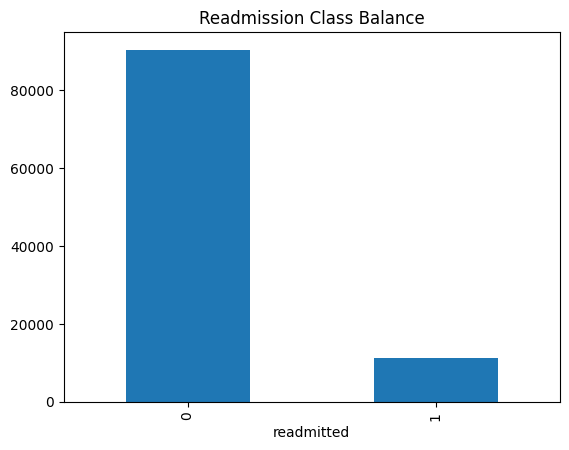

In [49]:
dia_df['readmitted'].value_counts().plot(kind='bar')
plt.title("Readmission Class Balance")

Text(0.5, 1.0, 'Readmission Rate by Age Group')

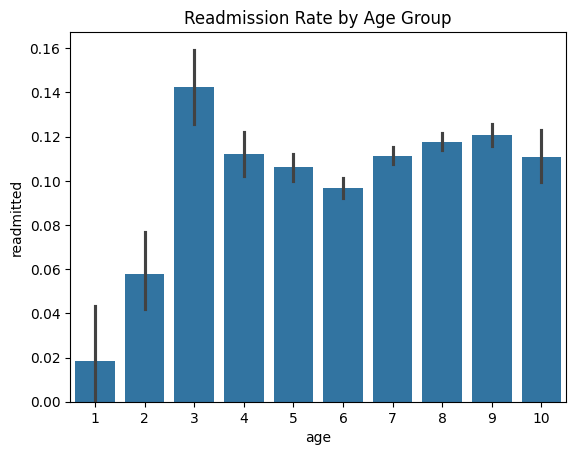

In [50]:
sns.barplot(x='age', y='readmitted', data=dia_df)
plt.title("Readmission Rate by Age Group")

Text(0.5, 1.0, 'Time in Hospital vs Readmission')

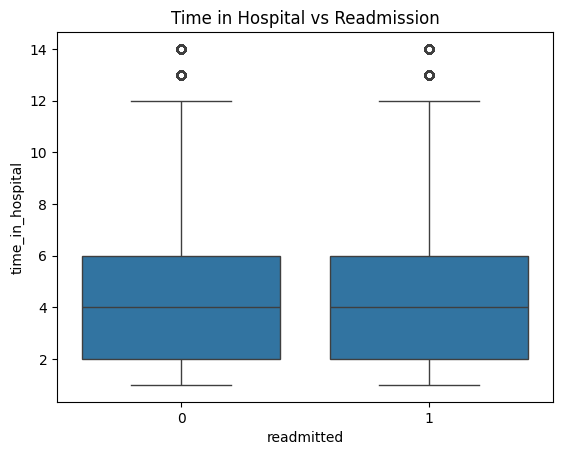

In [51]:
sns.boxplot(x='readmitted', y='time_in_hospital', data=dia_df)
plt.title("Time in Hospital vs Readmission")

# TRAINING THE MODEL

In [54]:
X = dia_df.drop('readmitted',axis = 1)
Y = dia_df['readmitted']

print(X.shape)
print(Y.shape)

(101763, 32)
(101763,)


In [55]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    Y,
    random_state=42,
    test_size=0.2,
    stratify= Y # ensure same class ratio
)

* encoding the categorical columns

In [56]:
categorical_cols = X_train.select_dtypes(include = 'object').columns.tolist()

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output= False , handle_unknown='ignore').fit(X_train[categorical_cols])

encoded = list(encoder.get_feature_names_out(categorical_cols))

X_train[encoded] = encoder.transform(X_train[categorical_cols])
X_test[encoded] = encoder.transform(X_test[categorical_cols])

X_train.drop(columns=categorical_cols, inplace=True)
X_test.drop(columns=categorical_cols, inplace=True)

* we are using SMOTE - Synthetic Minority Oversampling Technique because the number of 0s > 1s. The model will definitly predict more 0s. SMOTE help us to rule that out and bring the number of 1s and 0s to equal number 

In [57]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After SMOTE: ", pd.Series(y_train_resampled).value_counts().to_dict())

Before SMOTE: {0: 72324, 1: 9086}
After SMOTE:  {0: 72324, 1: 72324}


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate(model, name):
    model.fit(X_train_resampled, y_train_resampled)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"ROC-AUC: {roc_auc_score(y_test, proba):.4f}")
    print(classification_report(y_test, preds))

evaluate(LogisticRegression(max_iter=100, random_state=42), "Logistic Regression")
evaluate(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), "Random Forest")
evaluate(XGBClassifier(n_estimators=100, random_state=42), "XGBoost")

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
ROC-AUC: 0.5707
              precision    recall  f1-score   support

           0       0.90      0.61      0.73     18082
           1       0.14      0.49      0.21      2271

    accuracy                           0.60     20353
   macro avg       0.52      0.55      0.47     20353
weighted avg       0.82      0.60      0.67     20353


Model: Random Forest
ROC-AUC: 0.6035
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.41      0.00      0.01      2271

    accuracy                           0.89     20353
   macro avg       0.65      0.50      0.48     20353
weighted avg       0.84      0.89      0.84     20353


Model: XGBoost
ROC-AUC: 0.6653
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18082
           1       0.45      0.03      0.05      2271

    accuracy                           0.89     20353
   macro avg  

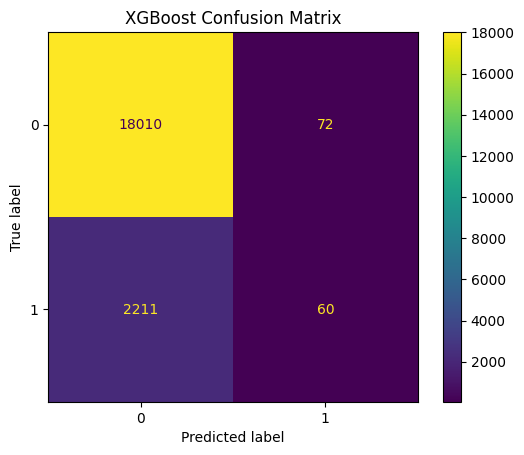

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = XGBClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_resampled, y_train_resampled)
preds = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.title("XGBoost Confusion Matrix")
plt.show()

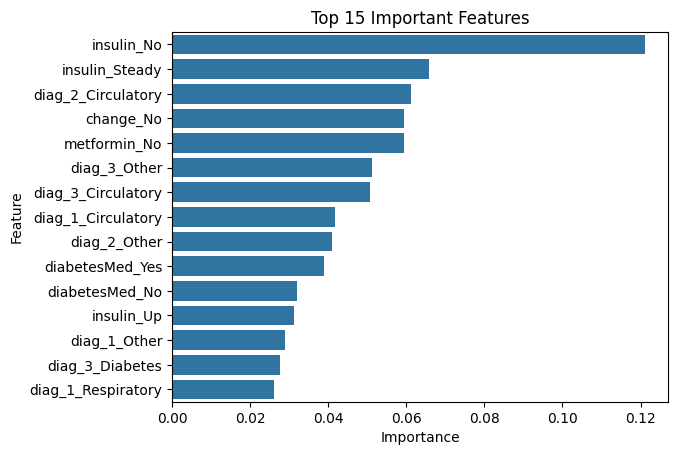

In [61]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Important Features")
plt.show()